# DeepONet: Poisson solutions from Gaussian random field inputs

This standalone notebook combines the DeepONet architecture and training workflow
from `01_deeponet_poisson.ipynb` with the Gaussian random field (GRF) sampling and
finite-difference Poisson solver from `09_grf_poisson_data.ipynb`.

We learn the function-to-function map

$$f(x)\longmapsto u(x),\qquad -u''(x)=f(x),\quad u(0)=u(1)=0.$$

The forcing functions now come from a zero-mean GRF with covariance

$$K(x,y)=\sigma^2\exp\left[-\frac{(x-y)^2}{2\ell^2}\right].$$

**What changes:** GRF samples replace the original random coefficients and basis
functions. Numerical Poisson solutions replace the original analytic target
formula. Every branch input and target comes from the **same sampled curve**.

**What stays:** 65 branch sensors, the branch/trunk neural networks, normalization
estimated from training data only, Adam with a cosine learning-rate schedule,
validation-based checkpoint selection, and a separate unseen test set.

Run the cells in order. Requires Python with NumPy, PyTorch, and Matplotlib.
If needed, install these in your notebook environment with
`%pip install numpy torch matplotlib`, then restart the kernel.
This is the driver notebook. GRF sampling lives in `grf.py`, the finite-difference
solver in `poisson.py`, the DeepONet architecture and training loop in `model.py`,
and the timing comparison in `benchmark.py`. Run it from the repository folder so
the modules import. Solver and model unit tests are in `tests/` (`pytest`).
Results are written under `artifacts/deeponet_poisson_grf` relative to the
notebook's working directory.

The reported errors compare with a finite-difference reference, not an exact
continuous solution. Testing uses new draws from the same GRF distribution;
it does not establish accuracy for arbitrary forcing functions.


In [1]:
import json
import platform
import time
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt

import benchmark
import grf
from model import DeepONet, interpolate_targets, train
from poisson import solve_poisson

OPERATOR = "poisson_grf"
DEVICE = "cpu"  # Choose "cuda" or "mps" only if available.
device = torch.device(DEVICE)
if device.type == "cuda" and not torch.cuda.is_available():
    raise RuntimeError("CUDA is not available in this runtime.")
if device.type == "mps" and not torch.backends.mps.is_available():
    raise RuntimeError("MPS is not available in this runtime.")
torch.set_num_threads(1)
MODEL_SEED = 1234
torch.manual_seed(MODEL_SEED)

# GRF and numerical reference settings from notebook 09.
N_GRID = 257
SIGMA = 1.0
LENGTH_SCALE = 0.2
JITTER = 1e-10

# Model/training settings from notebook 01.
N_SENSORS = 65
N_TRAIN = 2048
N_VALIDATION = 256
N_TEST = 512
WIDTH = 64
LATENT_DIM = 64
N_STEPS = 20000
BATCH_SIZE = 64
N_QUERIES = 64
VALIDATE_EVERY = 500

TRAIN_SEED, VALIDATION_SEED, TEST_SEED, BATCH_SEED = 100, 200, 900, 400
assert N_GRID >= 3 and 2 <= N_SENSORS <= N_GRID
assert (N_GRID - 1) % (N_SENSORS - 1) == 0, "Sensors must lie on the solution grid."
assert min(N_TRAIN, N_VALIDATION, N_TEST, N_STEPS, BATCH_SIZE, VALIDATE_EVERY) > 0
assert N_QUERIES >= 2 and SIGMA > 0 and LENGTH_SCALE > 0 and JITTER > 0

OUTPUT_DIR = Path("artifacts") / f"deeponet_{OPERATOR}"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Operator: {OPERATOR} | Device: {device}")
print(f"GRF: zero mean, sigma={SIGMA}, length scale={LENGTH_SCALE}")


Operator: poisson_grf | Device: cpu
GRF: zero mean, sigma=1.0, length scale=0.2


## 1. Sample complete forcing curves from one GRF

The covariance matrix is computed once on a 257-point grid. Cholesky
factorization gives $LL^T=K+\text{jitter}\,I$. Multiplying independent Gaussian
vectors by $L$ gives correlated function values. The tiny diagonal jitter
stabilizes the factorization, as in notebook 09.

Each row returned by `sample_grf` is one forcing curve. The same covariance is
used for every split, with separate random seeds. A zero mean refers to an
average across random draws; each individual curve can have a nonzero average.

The 65 branch sensors are a subset of this grid (every fourth point at the default
resolution). We **do not sample a second independent curve at the sensors**.


In [2]:
grid = np.linspace(0.0, 1.0, N_GRID, dtype=np.float64)
dx = grid[1] - grid[0]
L = grf.cholesky_factor(grid, LENGTH_SCALE, SIGMA, JITTER)
sensor_indices = grf.sensor_indices(N_GRID, N_SENSORS)

train_forcing = grf.sample_grf(L, N_TRAIN, TRAIN_SEED)
validation_forcing = grf.sample_grf(L, N_VALIDATION, VALIDATION_SEED)
# The test split is created only after model selection.
print("Covariance factor:", L.shape)
print("Training forcing curves:", train_forcing.shape)
print("Validation forcing curves:", validation_forcing.shape)
print("Branch sensor count:", len(sensor_indices))

Covariance factor: (257, 257)
Training forcing curves: (2048, 257)
Validation forcing curves: (256, 257)
Branch sensor count: 65


The length scale sets how wiggly the forcing functions are. The figure below uses
the same random vector $z$ in every row and changes only $\ell$. For a
squared-exponential GRF the expected number of zero crossings on $[0, 1]$ is
$1/(\pi\ell)$ (Rice's formula). The seed is chosen so each row shows a
typical number of crossings. The model is trained and tested only at the
`LENGTH_SCALE` set above.

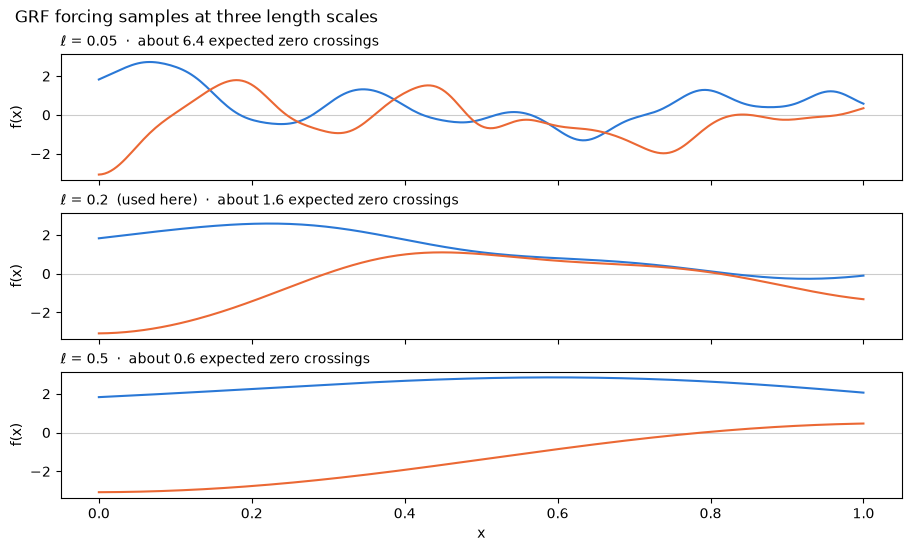

In [3]:
length_scales = sorted({0.05, LENGTH_SCALE, 0.5})
fig, axes = plt.subplots(len(length_scales), 1, figsize=(9, 1.8 * len(length_scales)),
                         sharex=True, sharey=True, layout="constrained")
for ax, length_scale in zip(axes, length_scales):
    L_demo = grf.cholesky_factor(grid, length_scale, SIGMA, JITTER)
    samples = grf.sample_grf(L_demo, 2, seed=13)  # same z in every row
    for sample, color in zip(samples, ("#2a78d6", "#eb6834")):
        ax.plot(grid, sample, color=color, lw=1.5)
    ax.axhline(0, color="0.8", lw=0.8, zorder=0)
    label = f"ℓ = {length_scale:g}" + ("  (used here)" if length_scale == LENGTH_SCALE else "")
    ax.set_title(f"{label}  ·  about {1 / (np.pi * length_scale):.1f} expected zero crossings",
                 loc="left", fontsize=10)
    ax.set_ylabel("f(x)")
axes[-1].set_xlabel("x")
fig.suptitle("GRF forcing samples at three length scales", x=0.01, ha="left")
fig.savefig(OUTPUT_DIR / "grf_length_scales.png", dpi=150)
plt.show()
plt.close(fig)

## 2. Solve Poisson to generate the training targets

At each interior grid point, the finite-difference equation is

$$\frac{-u_{i-1}+2u_i-u_{i+1}}{h^2}=f_i.$$

This is the same solver as notebook 09, with all right-hand sides solved together
for efficiency. The 255 interior solution values are unknown; the two endpoint
values of $u$ are fixed at zero. The forcing $f$ may be nonzero at the endpoints.

The neural network receives sampled forcing values, not random coefficients or
the numerical solution. The numerical solution is used only as the target.


In [4]:
train_solutions = solve_poisson(train_forcing, grid)
validation_solutions = solve_poisson(validation_forcing, grid)

sensors = torch.as_tensor(grid[sensor_indices], dtype=torch.float32, device=device).reshape(-1, 1)
validation_x = torch.as_tensor(grid, dtype=torch.float32, device=device).reshape(-1, 1)
train_inputs_raw = torch.as_tensor(train_forcing[:, sensor_indices], dtype=torch.float32, device=device)
validation_inputs_raw = torch.as_tensor(validation_forcing[:, sensor_indices], dtype=torch.float32, device=device)
train_targets = torch.as_tensor(train_solutions, dtype=torch.float32, device=device)
validation_targets = torch.as_tensor(validation_solutions, dtype=torch.float32, device=device)

# Estimate both normalizations from training functions only.
input_scale = train_inputs_raw.square().mean().sqrt()
output_scale = train_targets.square().mean().sqrt()
if input_scale.item() <= 0 or output_scale.item() <= 0:
    raise ValueError("Training data must have nonzero input and output scales.")
train_inputs = train_inputs_raw / input_scale
validation_inputs = validation_inputs_raw / input_scale

print(f"Train: {N_TRAIN} functions | Validation: {N_VALIDATION} functions")
print(f"Branch input: {N_SENSORS} sampled forcing values")
print(f"Reference solution: {N_GRID} grid values per function")
print(f"Training RMS scales: input={input_scale.item():.6g}, output={output_scale.item():.6g}")


Train: 2048 functions | Validation: 256 functions
Branch input: 65 sampled forcing values
Reference solution: 257 grid values per function
Training RMS scales: input=1.0056, output=0.0681192


## 3. Check the data construction

We verify the solver using $f(x)=1$, whose exact solution is $x(1-x)/2$, and
check that a sine forcing converges at second order as the grid is refined.
We also check the sampled data's discrete residual, zero solution endpoints,
and interpolation at the original grid points.

These checks distinguish solving the discrete linear system accurately from
approximating the continuous differential equation accurately.


In [5]:
constant_solution = solve_poisson(np.ones(N_GRID), grid)
constant_error = np.max(np.abs(constant_solution - grid * (1 - grid) / 2))
np.testing.assert_allclose(constant_solution, grid * (1 - grid) / 2, atol=1e-10, rtol=0)

sine_errors = []
for n_points in (65, 129, 257):
    check_grid = np.linspace(0, 1, n_points)
    forcing = np.sin(np.pi * check_grid)
    reference = forcing / np.pi**2
    sine_errors.append(np.max(np.abs(solve_poisson(forcing, check_grid) - reference)))
refinement_ratios = np.asarray(sine_errors[:-1]) / np.asarray(sine_errors[1:])
assert np.all((refinement_ratios > 3.9) & (refinement_ratios < 4.1))

residual = (-train_solutions[:, :-2] + 2 * train_solutions[:, 1:-1]
            - train_solutions[:, 2:]) / dx**2 - train_forcing[:, 1:-1]
max_discrete_residual = float(np.max(np.abs(residual)))
assert max_discrete_residual < 1e-8 * max(1.0, float(np.max(np.abs(train_forcing))))
assert np.all(train_solutions[:, [0, -1]] == 0)
assert np.all(validation_solutions[:, [0, -1]] == 0)
torch.testing.assert_close(interpolate_targets(train_targets[:3], validation_x),
                           train_targets[:3], rtol=1e-5, atol=1e-7)

print(f"Constant-forcing max error: {constant_error:.3e}")
print("Sine-forcing refinement ratios (expected about 4):", refinement_ratios)
print(f"Training max discrete residual: {max_discrete_residual:.3e}")
print("Solution endpoints and target interpolation: passed")


Constant-forcing max error: 4.441e-15
Sine-forcing refinement ratios (expected about 4): [4.00036147 4.00009035]
Training max discrete residual: 8.539e-12
Solution endpoints and target interpolation: passed


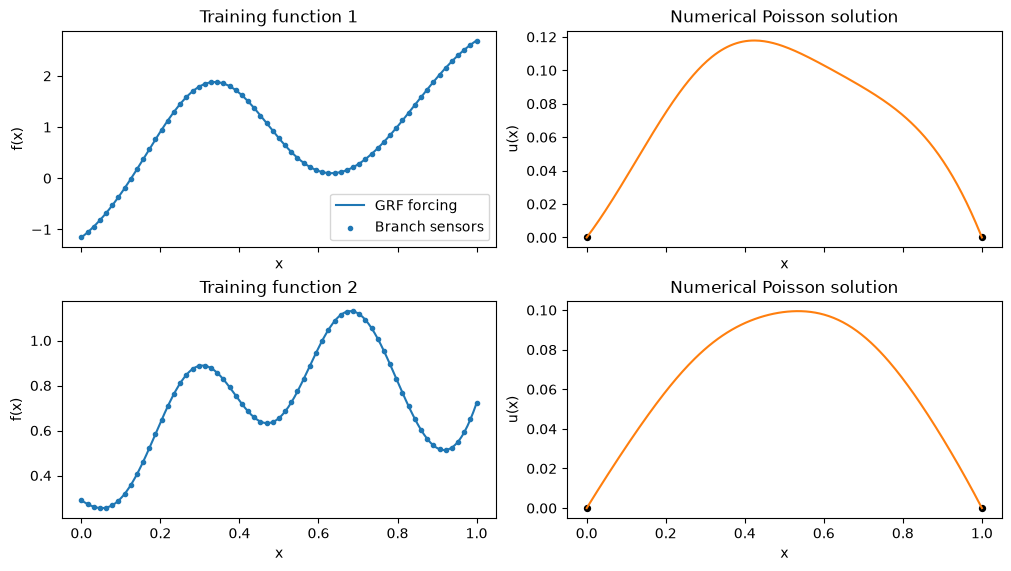

In [6]:
# Fixed training examples, showing the actual GRF inputs and numerical targets.
n_examples = min(2, N_TRAIN)
fig, axes = plt.subplots(n_examples, 2, figsize=(10, 2.8 * n_examples),
                         squeeze=False, sharex=True, layout="constrained")
for j in range(n_examples):
    axes[j, 0].plot(grid, train_forcing[j], label="GRF forcing")
    axes[j, 0].scatter(grid[sensor_indices], train_forcing[j, sensor_indices],
                       s=9, label="Branch sensors")
    axes[j, 0].set(title=f"Training function {j + 1}", xlabel="x", ylabel="f(x)")
    axes[j, 1].plot(grid, train_solutions[j], color="tab:orange")
    axes[j, 1].scatter([0, 1], [0, 0], color="black", s=18)
    axes[j, 1].set(title="Numerical Poisson solution", xlabel="x", ylabel="u(x)")
axes[0, 0].legend()
fig.savefig(OUTPUT_DIR / "grf_training_pairs.png", dpi=150)
plt.show()
plt.close(fig)


## 4. Train the original DeepONet architecture

The branch network sees 65 normalized forcing samples. The trunk network sees
one query coordinate $x$. Their feature vectors are combined to predict $u(x)$.

Each update selects a batch of functions and new query coordinates, including
both endpoints. Because the reference solutions are numerical grid values, we
linearly interpolate them at those queries. Validation compares predictions with
the grid reference on independently sampled validation functions.

As in notebook 01, zero boundary values are learned from target examples rather
than imposed by changing the neural-network architecture. The checkpoint with
the lowest validation error is restored before testing.


In [7]:
model = DeepONet(N_SENSORS, WIDTH, LATENT_DIM).to(device)
print(model)
print("Trainable parameters:", sum(parameter.numel() for parameter in model.parameters()))

DeepONet(
  (branch): Sequential(
    (0): Linear(in_features=65, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): Tanh()
    (4): Linear(in_features=64, out_features=64, bias=True)
  )
  (trunk): Sequential(
    (0): Linear(in_features=1, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): Tanh()
    (4): Linear(in_features=64, out_features=64, bias=True)
  )
)
Trainable parameters: 20993


In [8]:
result = train(
    model, train_inputs, train_targets, output_scale,
    validation_inputs, validation_x, validation_targets,
    n_steps=N_STEPS, batch_size=BATCH_SIZE, n_queries=N_QUERIES,
    validate_every=VALIDATE_EVERY, batch_seed=BATCH_SEED, device=device,
)
train_history = result["train_history"]
validation_history = result["validation_history"]
best_step = result["best_step"]
best_validation_error = result["best_validation_error"]
training_seconds = result["training_seconds"]
print(f"Selected step {best_step} by validation error: {best_validation_error:.3%}")
print(f"Training time: {training_seconds:.2f} s")

Step  2000 | MSE 5.879e-03 | validation relative L2 6.417%


Step  4000 | MSE 1.720e-03 | validation relative L2 6.000%


Step  6000 | MSE 6.859e-04 | validation relative L2 2.926%


Step  8000 | MSE 4.618e-04 | validation relative L2 2.554%


Step 10000 | MSE 4.743e-04 | validation relative L2 1.913%


Step 12000 | MSE 3.313e-04 | validation relative L2 1.487%


Step 14000 | MSE 1.457e-04 | validation relative L2 1.153%


Step 16000 | MSE 9.676e-05 | validation relative L2 1.038%


Step 18000 | MSE 7.699e-05 | validation relative L2 1.019%


Step 20000 | MSE 7.568e-05 | validation relative L2 0.968%
Selected step 20000 by validation error: 0.968%
Training time: 7.57 s


## 5. Evaluate on unseen GRF forcing functions

The test curves are first generated here, after checkpoint selection. They use
the same GRF settings but a separate random seed. All reported solution errors
are measured against numerical Poisson references, in original physical scale.
The mean-output and zero-output baselines show how much the network gains by
using the input function. The maximum predicted endpoint error is reported too.


In [9]:
# First use of this split: training and checkpoint selection are complete.
test_forcing = grf.sample_grf(L, N_TEST, TEST_SEED)
test_solutions = solve_poisson(test_forcing, grid)
test_x = validation_x.clone()
test_inputs = torch.as_tensor(test_forcing[:, sensor_indices], dtype=torch.float32, device=device)
reference_outputs = torch.as_tensor(test_solutions, dtype=torch.float32, device=device)
with torch.no_grad():
    predicted_outputs = model(test_inputs / input_scale, test_x) * output_scale

error = predicted_outputs - reference_outputs
per_function_error = torch.linalg.vector_norm(error, dim=1)
per_function_error /= torch.linalg.vector_norm(reference_outputs, dim=1).clamp_min(1e-12)
global_relative_error = torch.linalg.vector_norm(error) / torch.linalg.vector_norm(reference_outputs)
zero_relative_error = torch.ones((), device=device)
# An input-independent baseline: the mean training output at each query point.
mean_prediction = train_targets.mean(dim=0, keepdim=True)
mean_relative_error = torch.linalg.vector_norm(mean_prediction - reference_outputs)
mean_relative_error /= torch.linalg.vector_norm(reference_outputs)

metrics = {
    "operator": OPERATOR,
    "device": str(device),
    "torch_version": str(torch.__version__),
    "numpy_version": np.__version__,
    "python_version": platform.python_version(),
    "training_seconds": training_seconds,
    "best_step": best_step,
    "validation_relative_l2": best_validation_error,
    "test_global_relative_l2": global_relative_error.item(),
    "test_median_relative_l2": per_function_error.median().item(),
    "test_p95_relative_l2": torch.quantile(per_function_error, 0.95).item(),
    "test_max_relative_l2": per_function_error.max().item(),
    "test_max_absolute_error": error.abs().max().item(),
    "zero_baseline_relative_l2": zero_relative_error.item(),
    "mean_baseline_relative_l2": mean_relative_error.item(),
    "test_functions": N_TEST,
    "test_query_points": len(test_x),
    "input_distribution": "zero-mean squared-exponential Gaussian random field",
    "sigma": SIGMA,
    "length_scale": LENGTH_SCALE,
    "jitter": JITTER,
    "n_grid": N_GRID,
    "reference_solver": "second-order centered finite differences, float64",
    "training_target_interpolation": "linear on the reference grid",
    "training_max_discrete_residual": max_discrete_residual,
    "test_max_boundary_absolute_error": predicted_outputs[:, [0, -1]].abs().max().item(),
    "n_sensors": N_SENSORS,
    "n_train": N_TRAIN,
    "n_validation": N_VALIDATION,
    "width": WIDTH,
    "latent_dim": LATENT_DIM,
    "n_steps": N_STEPS,
    "batch_size": BATCH_SIZE,
    "n_queries": N_QUERIES,
    "model_seed": MODEL_SEED,
    "train_seed": TRAIN_SEED,
    "validation_seed": VALIDATION_SEED,
    "test_seed": TEST_SEED,
    "batch_seed": BATCH_SEED,
}
print(f"Unseen test functions: {N_TEST}")
print(f"Global relative L2: {metrics['test_global_relative_l2']:.3%}")
print(f"Per-function relative L2: median: {metrics['test_median_relative_l2']:.3%}, "
      f"95th percentile: {metrics['test_p95_relative_l2']:.3%}, max: {metrics['test_max_relative_l2']:.3%}")
print(f"Maximum absolute error: {metrics['test_max_absolute_error']:.3e}")
print(f"Mean-function baseline relative L2: {metrics['mean_baseline_relative_l2']:.3%}")

print(f"Maximum predicted boundary error: {metrics['test_max_boundary_absolute_error']:.3e}")


Unseen test functions: 512
Global relative L2: 1.143%
Per-function relative L2: median: 1.193%, 95th percentile: 5.145%, max: 15.804%
Maximum absolute error: 1.237e-02
Mean-function baseline relative L2: 100.062%
Maximum predicted boundary error: 4.540e-03


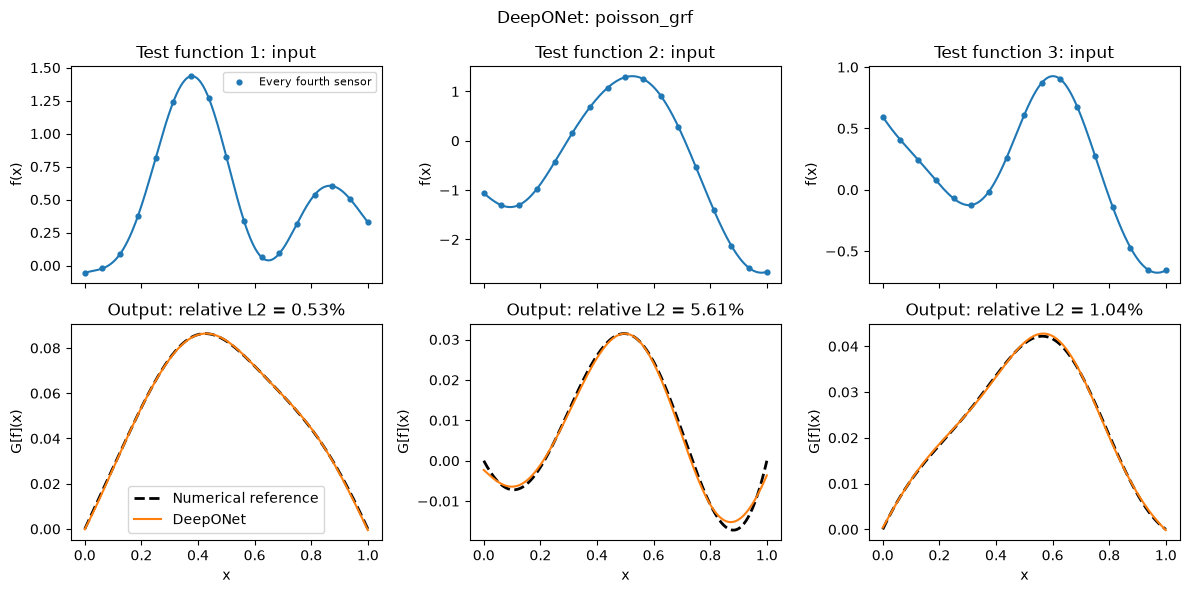

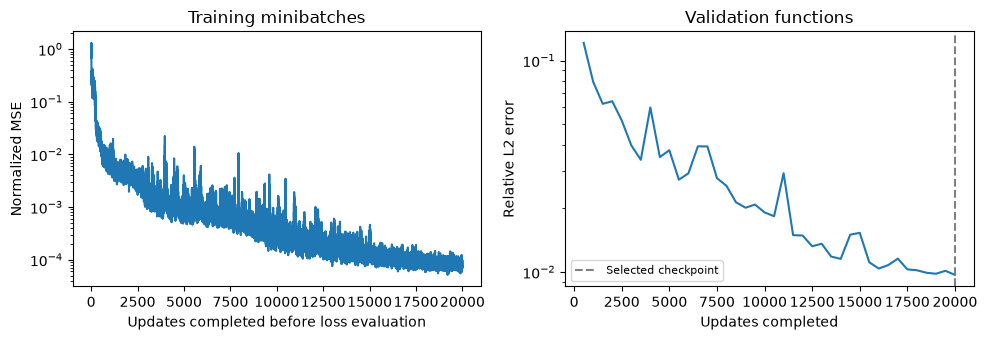

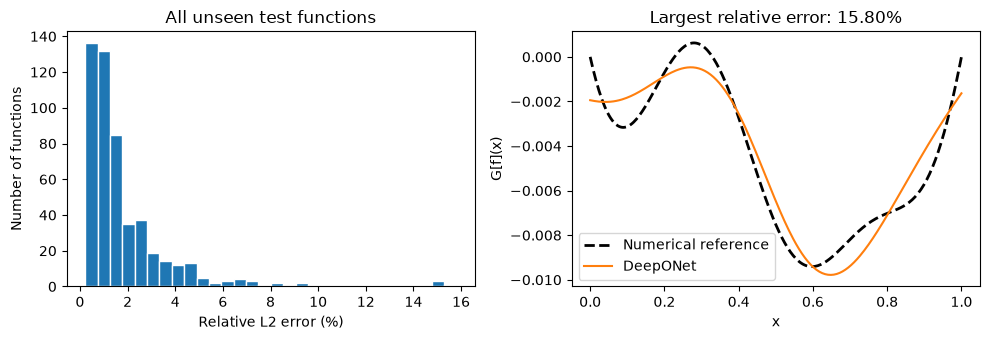

In [10]:
x_plot = test_x.cpu().numpy().ravel()
input_curves = test_forcing
true_curves = reference_outputs.cpu().numpy()
predicted_curves = predicted_outputs.cpu().numpy()
relative_errors = per_function_error.cpu().numpy()

# Fixed indices: these examples are not selected for small errors.
n_examples = min(3, N_TEST)
fig, axes = plt.subplots(2, n_examples, figsize=(4 * n_examples, 6), sharex=True, squeeze=False)
for column, sample in enumerate(range(n_examples)):
    axes[0, column].plot(x_plot, input_curves[sample], color="tab:blue")
    axes[0, column].scatter(sensors.cpu().numpy()[::4], test_inputs[sample].cpu().numpy()[::4],
                            s=12, color="tab:blue", label="Every fourth sensor")
    axes[0, column].set_title(f"Test function {sample + 1}: input")
    axes[0, column].set_ylabel("f(x)")
    axes[1, column].plot(x_plot, true_curves[sample], "k--", lw=2, label="Numerical reference")
    axes[1, column].plot(x_plot, predicted_curves[sample], color="tab:orange", lw=1.5, label="DeepONet")
    axes[1, column].set_title(f"Output: relative L2 = {relative_errors[sample]:.2%}")
    axes[1, column].set_xlabel("x")
    axes[1, column].set_ylabel("G[f](x)")
axes[0, 0].legend(fontsize=8)
axes[1, 0].legend()
fig.suptitle(f"DeepONet: {OPERATOR}")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "predictions.png", dpi=150)
plt.show()
plt.close(fig)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].semilogy(np.arange(N_STEPS), train_history)
axes[0].set(xlabel="Updates completed before loss evaluation", ylabel="Normalized MSE", title="Training minibatches")
validation_array = np.asarray(validation_history)
axes[1].semilogy(validation_array[:, 0], validation_array[:, 1])
axes[1].axvline(best_step, color="0.5", ls="--", label="Selected checkpoint")
axes[1].set(xlabel="Updates completed", ylabel="Relative L2 error", title="Validation functions")
axes[1].legend(fontsize=8)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "training.png", dpi=150)
plt.show()
plt.close(fig)

worst_sample = int(relative_errors.argmax())
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].hist(100 * relative_errors, bins=30, color="tab:blue", edgecolor="white")
axes[0].set(xlabel="Relative L2 error (%)", ylabel="Number of functions", title="All unseen test functions")
axes[1].plot(x_plot, true_curves[worst_sample], "k--", lw=2, label="Numerical reference")
axes[1].plot(x_plot, predicted_curves[worst_sample], color="tab:orange", label="DeepONet")
axes[1].set(xlabel="x", ylabel="G[f](x)", title=f"Largest relative error: {relative_errors[worst_sample]:.2%}")
axes[1].legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "test_errors.png", dpi=150)
plt.show()
plt.close(fig)


## 6. Save the trained model and the data

`model.pt` includes weights, normalization scales, architecture settings, sensor
coordinates, and GRF settings. `grf_poisson_dataset.npz` contains all three
splits of sampled forcing curves and numerical solutions, so the data can be
inspected or reused independently of this notebook. `test_predictions.npz`
contains held-out predictions and error histories. `metrics.json` records the
configuration and measured errors. All arrays in these files are unnormalized
unless explicitly described as a training loss.


In [11]:
(OUTPUT_DIR / "metrics.json").write_text(json.dumps(metrics, indent=2) + "\n")
torch.save({
    "state_dict": {name: tensor.detach().cpu() for name, tensor in model.state_dict().items()},
    "input_scale": input_scale.cpu(),
    "output_scale": output_scale.cpu(),
    "operator": OPERATOR,
    "n_sensors": N_SENSORS,
    "width": WIDTH,
    "latent_dim": LATENT_DIM,
    "sensors": sensors.cpu(),
    "grid": test_x.cpu(),
    "sigma": SIGMA,
    "length_scale": LENGTH_SCALE,
    "jitter": JITTER,
    "best_step": best_step,
}, OUTPUT_DIR / "model.pt")
np.savez_compressed(
    OUTPUT_DIR / "grf_poisson_dataset.npz",
    x=grid, sensors=grid[sensor_indices], sensor_indices=sensor_indices,
    train_forcing=train_forcing, train_solutions=train_solutions,
    validation_forcing=validation_forcing, validation_solutions=validation_solutions,
    test_forcing=test_forcing, test_solutions=test_solutions,
    sigma=SIGMA, length_scale=LENGTH_SCALE, jitter=JITTER,
    train_seed=TRAIN_SEED, validation_seed=VALIDATION_SEED, test_seed=TEST_SEED,
)
np.savez_compressed(
    OUTPUT_DIR / "test_predictions.npz",
    x=x_plot, sensors=sensors.cpu().numpy().ravel(),
    input_values=test_inputs.cpu().numpy(), full_forcing=test_forcing,
    reference_outputs=true_curves, predicted_outputs=predicted_curves,
    per_function_relative_l2=relative_errors,
    train_history=np.asarray(train_history), validation_history=validation_array,
)
print("Saved model, GRF data, metrics, predictions, and plots to", OUTPUT_DIR.resolve())


Saved model, GRF data, metrics, predictions, and plots to /Users/andrewdunnbeltran/Resume/deeponet-poisson-grf/artifacts/deeponet_poisson_grf


## 7. Predict for a new sampled curve

This last example uses one additional GRF draw with a new seed. The sampled
sensor values are the model input; the numerical solver is called only to
check the prediction. It is not needed to make a prediction.

To make a new experiment, change `LENGTH_SCALE`, `SIGMA`, or the split sizes in
the settings cell and rerun from the top. Changing the kernel parameters defines
a different input distribution. A model trained at one length scale is not
automatically validated at another. Smaller length scales may require finer
reference grids and more branch sensors; keep the sensor grid aligned.


New GRF sample, seed 2026: relative L2 = 1.460%


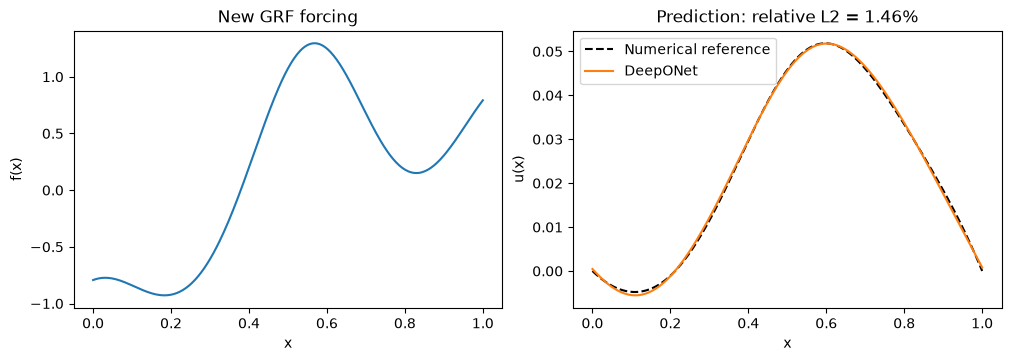

In [12]:
NEW_SAMPLE_SEED = 2026
new_forcing = grf.sample_grf(L, 1, NEW_SAMPLE_SEED)
new_sensor_values = torch.as_tensor(new_forcing[:, sensor_indices], dtype=torch.float32, device=device)
model.eval()
with torch.no_grad():
    new_prediction = (model(new_sensor_values / input_scale, test_x) * output_scale).cpu().numpy()[0]
new_reference = solve_poisson(new_forcing, grid)[0]
new_relative_error = np.linalg.norm(new_prediction - new_reference) / max(np.linalg.norm(new_reference), 1e-12)
print(f"New GRF sample, seed {NEW_SAMPLE_SEED}: relative L2 = {new_relative_error:.3%}")

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), layout="constrained")
axes[0].plot(grid, new_forcing[0])
axes[0].set(title="New GRF forcing", xlabel="x", ylabel="f(x)")
axes[1].plot(grid, new_reference, "k--", label="Numerical reference")
axes[1].plot(grid, new_prediction, color="tab:orange", label="DeepONet")
axes[1].set(title=f"Prediction: relative L2 = {new_relative_error:.2%}", xlabel="x", ylabel="u(x)")
axes[1].legend()
fig.savefig(OUTPUT_DIR / "new_grf_prediction.png", dpi=150)
plt.show()
plt.close(fig)


## 8. Inference cost versus the numerical solver

Accuracy alone does not justify a surrogate; the point of learning the operator is
that evaluating it should be cheaper than solving the boundary-value problem. This
section measures both with `time.perf_counter()`, using the already-trained model
and the same GRF test curves.

Two finite-difference variants are timed, because the comparison is sensitive to
which one is used as the baseline:

- **rebuild:** `solve_poisson` exactly as called above. Each call assembles the
  $255\times255$ operator and runs a fresh dense LU factorization, so the
  factorization cost is paid on every batch.
- **reuse:** the discrete operator is factored once (here, inverted once) and the
  same factorization is applied to new forcing vectors. This is what a solver
  would do in production on a fixed grid, and it is the harder baseline.

Every routine is warmed up once and then repeated, and the median is reported to
limit the effect of scheduler noise. Timings are taken across several batch sizes,
since both the network and the solver amortize fixed overhead over a batch. Note
that the network runs in float32 and the solver in float64, and the one-off
training cost is excluded from the per-call numbers but reported separately as a
break-even count.

Device: cpu | torch threads: 1 | queries per function: 257
One-off operator factorization: 0.42 ms

 batch |      network |   FD rebuild |     FD reuse | vs rebuild |  vs reuse
----------------------------------------------------------------------------
     1 |     135.8 us |     279.8 us |       4.5 us |      2.06x |     0.03x
     8 |      17.4 us |      34.9 us |       1.6 us |      2.01x |     0.09x
    64 |       2.7 us |       5.1 us |       0.5 us |      1.85x |     0.20x
   256 |       1.0 us |       2.5 us |       0.4 us |      2.46x |     0.40x

Times are per forcing function; speedups above 1 favor the network.

Training cost: 7.6 s, excluded from the per-call times above.
At batch 256, training pays for itself after about 5,081,945 solves versus the rebuild baseline.
Accuracy cost of the substitution: test relative L2 = 1.143% against the float64 finite-difference reference.


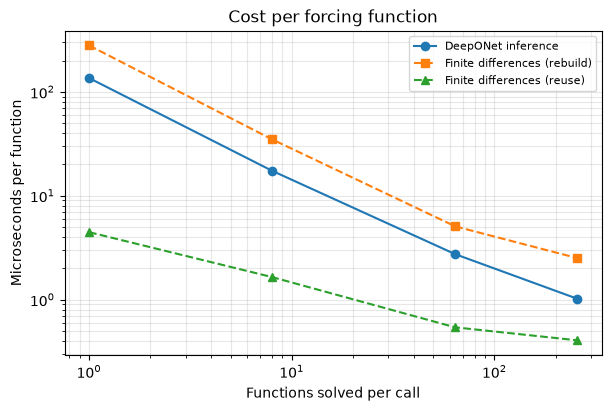

Saved timing results to /Users/andrewdunnbeltran/Resume/deeponet-poisson-grf/artifacts/deeponet_poisson_grf/timing.json


In [13]:
# Cost of evaluating the trained operator against the finite-difference solver.
N_TIMING = min(256, N_TEST)
N_REPEATS = 7
BATCH_SIZES = tuple(size for size in (1, 8, 64, 256) if size <= N_TIMING)
assert BATCH_SIZES, "Need at least one timing batch size."

timing = benchmark.run_benchmark(
    model, test_x, output_scale,
    test_inputs[:N_TIMING] / input_scale, test_forcing[:N_TIMING], grid,
    batch_sizes=BATCH_SIZES, n_repeats=N_REPEATS, device=device,
)
timings = timing["rows"]
factorization_seconds = timing["operator_factorization_seconds"]

print(f"Device: {device} | torch threads: {torch.get_num_threads()} | "
      f"queries per function: {len(test_x)}")
print(f"One-off operator factorization: {1e3 * factorization_seconds:.2f} ms\n")
benchmark.print_table(timings)

largest = timings[-1]
break_even = benchmark.break_even_solves(training_seconds, largest)
print(f"\nTraining cost: {training_seconds:.1f} s, excluded from the per-call times above.")
if np.isfinite(break_even):
    print(f"At batch {largest['batch']}, training pays for itself after about "
          f"{break_even:,.0f} solves versus the rebuild baseline.")
else:
    print("The network is not faster than the rebuild baseline here, so training never pays for itself on speed alone.")
print(f"Accuracy cost of the substitution: test relative L2 = {global_relative_error.item():.3%} "
      "against the float64 finite-difference reference.")

fig, ax = plt.subplots(figsize=(6, 4), layout="constrained")
batches = [row["batch"] for row in timings]
for key, label, style in (("network", "DeepONet inference", "o-"),
                          ("rebuild", "Finite differences (rebuild)", "s--"),
                          ("reuse", "Finite differences (reuse)", "^--")):
    ax.loglog(batches, [row[f"{key}_microseconds_per_function"] for row in timings], style, label=label)
ax.set(xlabel="Functions solved per call", ylabel="Microseconds per function",
       title="Cost per forcing function")
ax.grid(True, which="both", alpha=0.3)
ax.legend(fontsize=8)
fig.savefig(OUTPUT_DIR / "timing.png", dpi=150)
plt.show()
plt.close(fig)

timing_metrics = {
    "device": str(device),
    "torch_threads": torch.get_num_threads(),
    "n_repeats": N_REPEATS,
    "queries_per_function": len(test_x),
    "n_grid": N_GRID,
    "network_dtype": "float32",
    "solver_dtype": "float64",
    "operator_factorization_seconds": factorization_seconds,
    "training_seconds": training_seconds,
    "break_even_solves_vs_rebuild": break_even,
    "test_global_relative_l2": global_relative_error.item(),
    "rows": timings,
}
(OUTPUT_DIR / "timing.json").write_text(json.dumps(timing_metrics, indent=2) + "\n")
print("Saved timing results to", (OUTPUT_DIR / "timing.json").resolve())